# Oasis Infobyte Internship

# Data Analytics - Level 1 Task 1

## Exploratory Data Analysis (EDA) on Retail Sales Data

**Intern Name:** Shivanand Prakash Birajdar

**Repository:** OIBSIP

**Dataset:** Retail Sales Dataset

### Objective
The objective of this project is to perform Exploratory Data Analysis (EDA) on a retail sales dataset to identify sales patterns, customer behavior, product performance, and business insights using Python.

### Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display graphs inside notebook
%matplotlib inline

# Improve plot appearance
sns.set_style("whitegrid")

# Display all columns
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
# Load the dataset
df = pd.read_csv("dataset/retail_sales_dataset.csv")

# Display first five rows
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [7]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset: (1000, 9)

Column Names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Data Types:
Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


## Initial Observation

- The dataset was successfully loaded into the notebook.
- The dataset contains customer demographics, transaction details, and sales information.
- The structure, data types, and missing values were examined to understand the quality of the data before analysis.
- The next step is to perform descriptive statistical analysis and verify data quality.

# Data Preparation

Before performing analysis, we convert the **Date** column into datetime format. This allows us to perform monthly and quarterly trend analysis efficiently.

After that, we generate descriptive statistics to understand the distribution of numerical variables.

In [8]:
# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Verify data types
df.dtypes

Transaction ID               int64
Date                datetime64[us]
Customer ID                    str
Gender                         str
Age                          int64
Product Category               str
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

In [9]:
# Descriptive Statistics
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [10]:
print("Mean Values")
print(df.mean(numeric_only=True))

print("\nMedian Values")
print(df.median(numeric_only=True))

print("\nMode Values")
print(df.mode(numeric_only=True).iloc[0])

print("\nStandard Deviation")
print(df.std(numeric_only=True))

Mean Values
Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median Values
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode Values
Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

Standard Deviation
Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


## Observation

- The descriptive statistics provide an overview of the numerical features in the dataset.
- Comparing the mean and median helps identify skewness in the data.
- The standard deviation indicates the spread of the values.
- These statistics help in understanding customer purchasing behaviour before visualization.

# Monthly Sales Trend

This analysis helps identify how total sales vary across different months. It reveals seasonal trends and helps businesses understand periods of high and low sales.

In [11]:
# Create Month and Quarter columns
df["Month"] = df["Date"].dt.month_name()
df["Month_Number"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter

In [12]:
# Monthly Sales
monthly_sales = (
    df.groupby(["Month_Number", "Month"])["Total Amount"]
      .sum()
      .reset_index()
      .sort_values("Month_Number")
)

monthly_sales

,Month_Number,Month,Total Amount
0,1,January,36980
1,2,February,44060
2,3,March,28990
3,4,April,33870
4,5,May,53150
5,6,June,36715
6,7,July,35465
7,8,August,36960
8,9,September,23620
9,10,October,46580


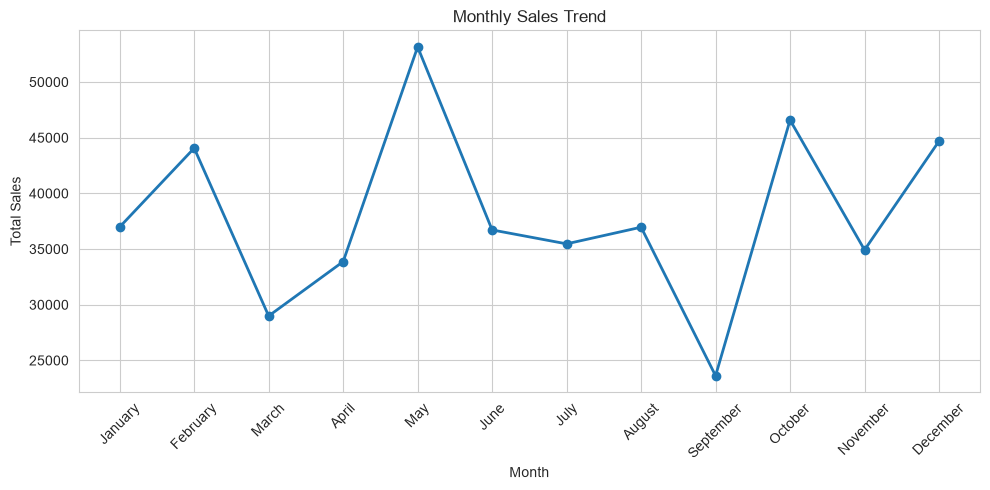

In [13]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Total Amount"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Observation

- The line chart shows the variation in total sales across different months.
- Peak sales months indicate higher customer demand.
- Low sales months may require promotional campaigns to improve revenue.

In [14]:
quarterly_sales = (
    df.groupby("Quarter")["Total Amount"]
      .sum()
      .reset_index()
)

quarterly_sales

,Quarter,Total Amount
0,1,110030
1,2,123735
2,3,96045
3,4,126190


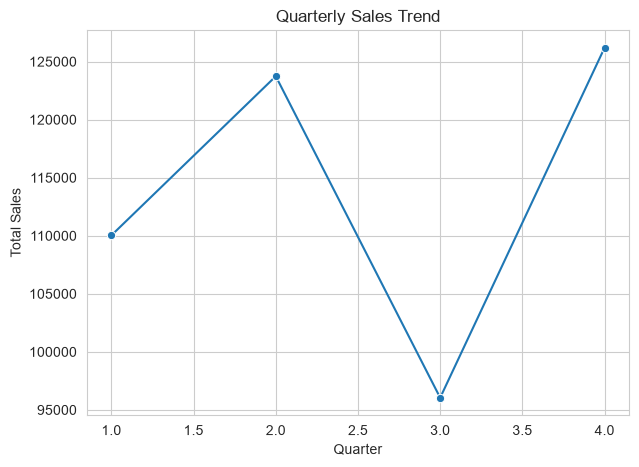

In [15]:
plt.figure(figsize=(7,5))

sns.lineplot(
    data=quarterly_sales,
    x="Quarter",
    y="Total Amount",
    marker="o"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.show()

## Observation

- Quarterly analysis provides a broader view of sales performance.
- Comparing quarters helps identify long-term business trends.
- Businesses can use these insights for inventory planning and sales forecasting.

# Customer Demographics Analysis

This section analyzes customer demographics based on age and gender. Understanding customer demographics helps businesses identify their primary target audience and create better marketing strategies.

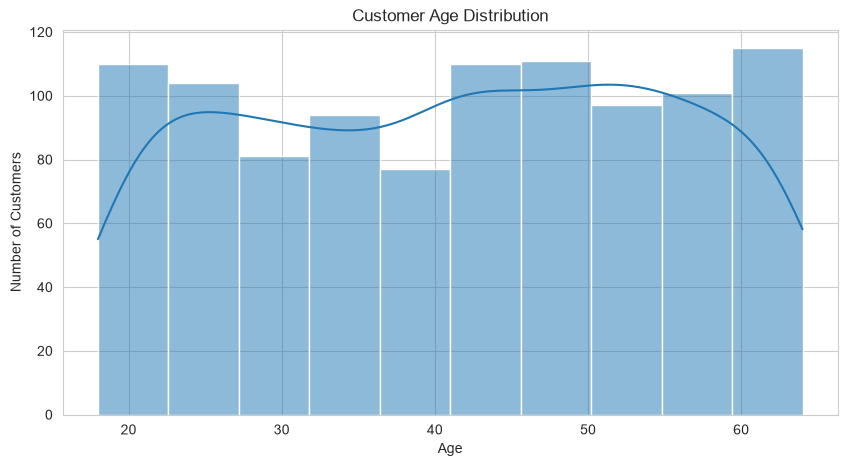

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(df["Age"], bins=10, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

## Observation

- The histogram shows the distribution of customers across different age groups.
- Businesses can identify the dominant customer age group.
- Marketing campaigns can be customized for the most active age segment.

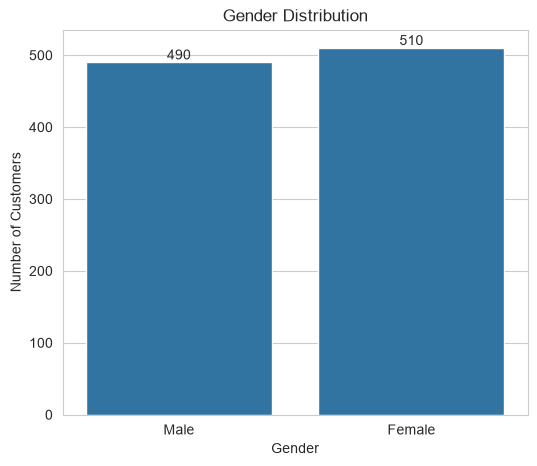

In [17]:
plt.figure(figsize=(6,5))

ax = sns.countplot(data=df, x="Gender")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

In [18]:
df["Gender"].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

## Observation

- The chart shows the number of male and female customers.
- The gender distribution helps understand customer preferences.
- Businesses can design targeted marketing campaigns based on customer demographics.

# Product Category Analysis

This section analyzes the sales performance of different product categories. It helps identify the most popular categories and their contribution to overall revenue.

In [19]:
category_sales = (
    df.groupby("Product Category")["Total Amount"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

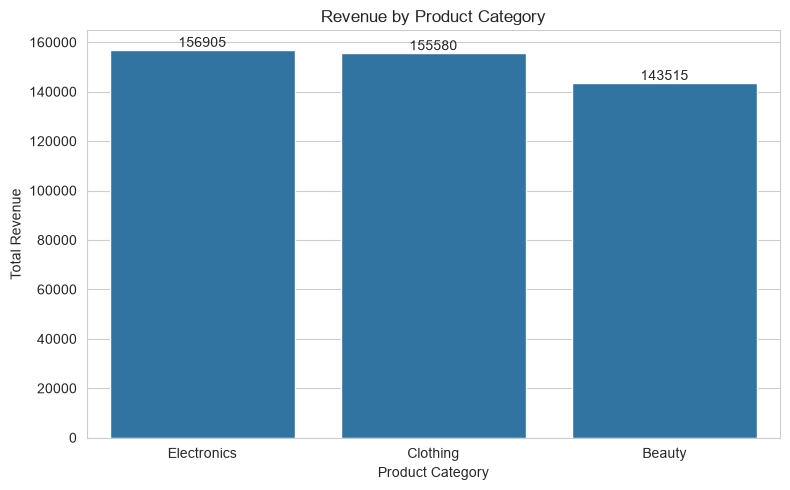

In [20]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

## Observation

- The bar chart compares the total revenue generated by each product category.
- The category with the highest revenue contributes the most to business growth.
- Low-performing categories may require promotional offers or inventory optimization.

In [21]:
top_categories = (
    df["Product Category"]
      .value_counts()
)

top_categories

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

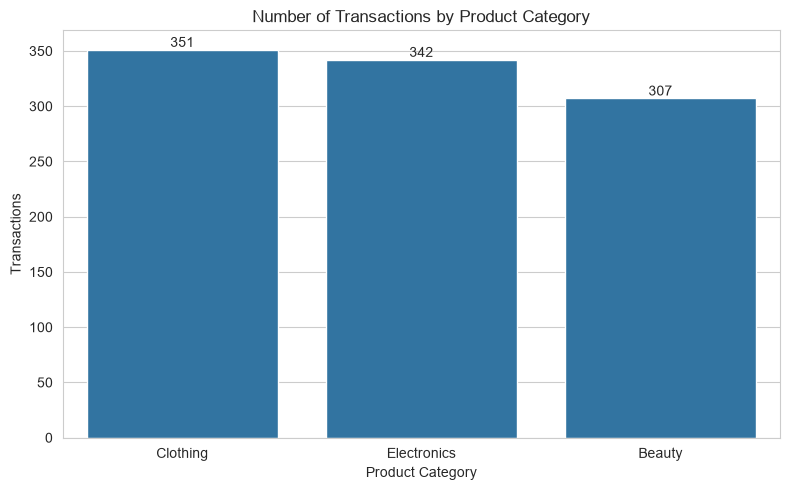

In [22]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Product Category",
    order=df["Product Category"].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Number of Transactions by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Transactions")

plt.tight_layout()
plt.show()

## Observation

- This chart shows the number of transactions for each product category.
- A category with more transactions is generally more popular among customers.
- Businesses can use this information for demand forecasting and stock management.

# Correlation Analysis

Correlation analysis helps identify the relationship between numerical variables in the dataset. It assists in understanding which features have the strongest positive or negative relationships.

In [ ]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Observation

- The heatmap illustrates the correlation between numerical variables.
- Strong positive values indicate that two variables increase together.
- Negative values indicate an inverse relationship.
- Correlation analysis helps identify important business factors influencing sales.

# Customer Spending by Age

This visualization examines whether customer age has any relationship with the total purchase amount.

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Total Amount",
    hue="Gender"
)

plt.title("Customer Age vs Total Purchase Amount")
plt.xlabel("Age")
plt.ylabel("Total Amount")

plt.show()

## Observation

- The scatter plot shows customer purchase amounts across different age groups.
- Spending patterns vary among customers of different ages.
- This analysis can help businesses identify valuable customer segments.

# Business Recommendations

Based on the exploratory data analysis, the following recommendations are suggested:

1. Focus marketing campaigns on the product category generating the highest revenue.
2. Introduce promotional offers during months with lower sales to improve overall revenue.
3. Analyze customer purchasing behavior across different age groups and genders to create targeted marketing strategies.

# Conclusion

This project successfully performed Exploratory Data Analysis (EDA) on a retail sales dataset.

Key findings include:

- Customer demographics provide valuable insights into purchasing behavior.
- Product category analysis identifies the strongest revenue-generating categories.
- Monthly and quarterly trends help understand seasonal sales patterns.
- Correlation analysis reveals relationships among numerical variables.

Overall, the analysis demonstrates how data-driven decision-making can improve sales performance, customer targeting, and business strategy.